Import all globally needed libraries for the project.

In [40]:
# Data Analysis
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Required
from datetime import datetime
import os

# DA
import matplotlib.pyplot as plt
import seaborn as sns

some required functions for later use.

In [53]:
def calc_rotation_angle(A: np.ndarray, B: np.ndarray, C: np.ndarray) -> float:
    AB = A - B
    BC = C - B

    dot = np.dot(AB, BC)
    cross = np.cross(AB, BC)

    angle = np.arctan2(cross, dot)
    return angle

def calc_finger_rot(row) -> np.ndarray:
    finger_data = np.array(row).reshape(5, 4, 3) # 5 Fingers, 4 Points, 3 x,y,z
    finger_rot = np.empty(5, dtype=np.float32)

    for i, landmark_points in enumerate(finger_data):
        # Slicing creates 2D vectors (x, y)
        p0 = landmark_points[0][0:2]
        p1 = landmark_points[1][0:2]
        p2 = landmark_points[2][0:2]
        p3 = landmark_points[3][0:2]
        
        finger_rot[i] = calc_rotation_angle(p0, (p1 + p2)/2, p3)

    return finger_rot

Configurations and Constant to be used in the main data processing part.

In [50]:
# Configuration & Constant
Q1_PERCENTILE : float = 0.20
Q3_PERCENTILE : float= 0.80
IQR_THRESHOLD : float = 1.5

In [54]:
dir_list = os.listdir('data')
processed_df : list = []
raw_df : list = []

for filepath in dir_list:
    if filepath in ['combined_data.csv', 'combined_data_raw.csv']:
        continue

    df_chunk = pd.read_csv(os.path.join('data', filepath))
    raw_df.append(df_chunk.copy(True))
    
    # -- Feature Engineering --
    # Remove NaN
    df_chunk.dropna(inplace=True)
    if df_chunk.empty:
        continue

    # Vectorize rotation calculation
    rotation_features = df_chunk.apply(calc_finger_rot, axis=1, result_type='expand')

    # Combine rotation features with original dataframe
    df_chunk.reset_index(drop=True, inplace=True)
    rotation_features.reset_index(drop=True, inplace=True)
    df_processed = pd.concat([
        df_chunk, rotation_features
    ], axis=1, ignore_index=True)

    # -- Outlier Removal --
    # Numbering columns
    numeric_cols = df_processed.select_dtypes(include=[np.number]).columns.tolist()

    # Calculate Q1, Q3, and IQR for each numeric column
    Q1 = df_processed[numeric_cols].quantile(Q1_PERCENTILE)
    Q3 = df_processed[numeric_cols].quantile(Q3_PERCENTILE)
    IQR = Q3 - Q1

    lower_bound = Q1 - (IQR_THRESHOLD * IQR)
    upper_bound = Q3 + (IQR_THRESHOLD * IQR)

    is_within_bounds = (df_processed[numeric_cols] >= lower_bound) & (df_processed[numeric_cols] <= upper_bound)

    # Number of Outliers
    # print(abs(is_within_bounds.sum() - len(df_processed)))

    df_filtered = df_processed[is_within_bounds.all(axis=1)].copy()

    df_filtered['label'] = filepath[0]
    print(f'Processing: {filepath[0]}, {dir_list.index(filepath)+1}/{len(dir_list)}', end='\r')
    processed_df.append(df_filtered)

if processed_df:
    main_df = pd.concat(processed_df, ignore_index=True)
    raw_df = pd.concat(raw_df, ignore_index=True)

    main_df.to_csv('data/combined_data.csv', index=False)
    raw_df.to_csv('data/combined_data_raw.csv', index=False)

    print(f"Processing complete. Final shape of processed data: {main_df.shape}")
else:
    print('No data was processed')

Processing complete. Final shape of processed data: (15615, 66)


Random Visualization :3

Now we will use dimensionality reduction technique. I will try t-SNE first, due to its better visualizer and not a 'black box'. This shows the correlation between hand signs.

In [ ]:
from sklearn.manifold import TSNE


Running t-SNE... This may take a moment.


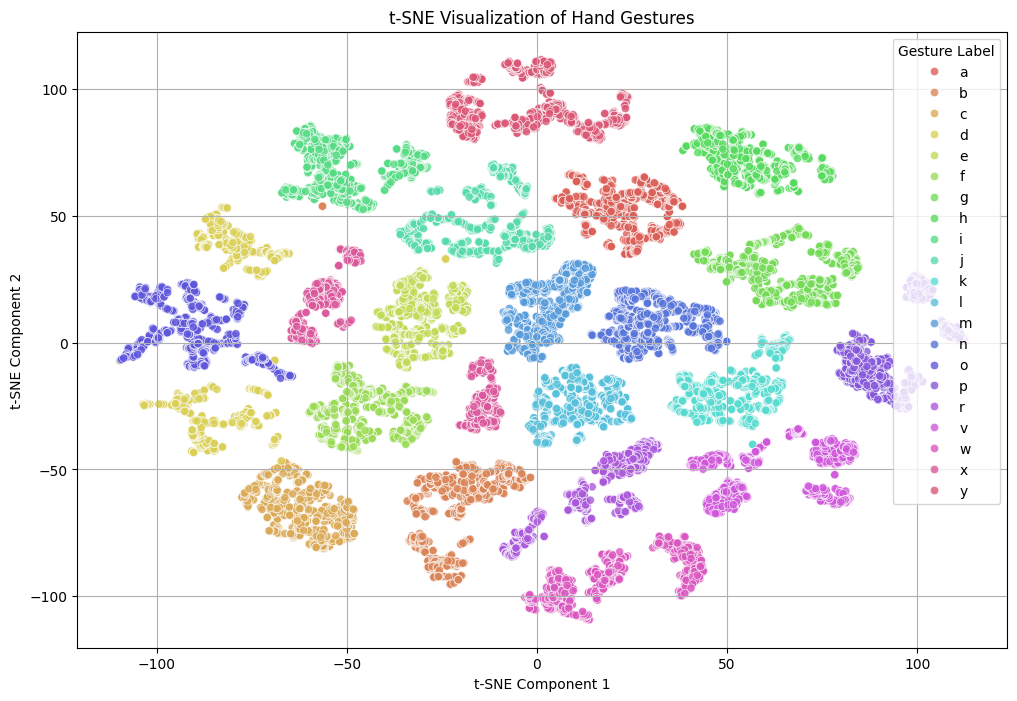

In [47]:
X = main_df.drop('label', axis=1)
y = main_df['label']

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 2. Apply t-SNE ---
print("Running t-SNE... This may take a moment.")
tsne = TSNE(
    n_components=2,   # We want a 2D plot
    perplexity=30,    # A common starting value
    learning_rate='auto',
    init='pca',       # Speeds up the process
    max_iter=1000,      # Number of iterations for optimization
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)


# --- 3. Visualize ---
# Create a new DataFrame for plotting
df_tsne = pd.DataFrame(data=X_tsne, columns=['Component 1', 'Component 2'])
df_tsne['label'] = y

# Create the scatter plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Component 1',
    y='Component 2',
    hue='label',      # Color points by their original label
    palette=sns.color_palette("hls", n_colors=len(df_tsne['label'].unique())),
    data=df_tsne,
    legend="full",
    alpha=0.8
)

plt.title('t-SNE Visualization of Hand Gestures')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(title='Gesture Label')
plt.grid(True)
plt.show()

Combine all the cleaned up data to *one* big csv corpus. Next we will split the data to Train, Test and Validate. After, we'll standardize the data using the scaler element that we'd mde earlier. The *main.df['label']* will get the categorical labels or the target of the data that should be recognize.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    main_df.drop('label', axis=1), 
    main_df['label'], 
    test_size=0.2, 
    random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

We will save the scaler to apply it for the input data later.

In [174]:
from joblib import dump as jldump

jldump(scaler, f'model/svc_scaler_{(str(datetime.now().date())).replace("-", "")}.pkl')

['model/svc_scaler_20251004.pkl']

Now we will make the machine learning (*ML*). There are a lot of machine learning model that can be our candidate. Some of them are Logical Regression and Tree-based. In here we will use Logical Reasoning due to Tree-based has troubles using high dimensional feature variable.

In [175]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train_scaled, y_train)

print(f'Here is the accuracy of LR for train set: {logreg.score(X_train_scaled, y_train)}')
print(f'Here is the accuracy of LR for test set: {logreg.score(X_test_scaled, y_test)}')


Here is the accuracy of LR for train set: 0.9999168191648644
Here is the accuracy of LR for test set: 1.0


Searching for the best model parameter with GridSearchCV

In [181]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'gamma': [0.01, 0.1, 1, 10, 100],
    'kernel': ['rbf']
}

In [182]:
from sklearn.svm import SVC

svc = SVC()

# cv=5 means 5-fold cross-validation
# verbose=3 displays a detailed log of the process
grid_search = GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    cv=5,
    verbose=3,
    scoring='accuracy', # The metric to optimize (e.g., 'accuracy', 'f1_weighted')
    n_jobs=-1           # Use all available CPU cores for speed
)

# NOTE: This trains the C * gamma * kernel
print("Starting GridSearchCV...")
grid_search.fit(X_train_scaled, y_train)
print("GridSearchCV finished.")

Starting GridSearchCV...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
GridSearchCV finished.


In [183]:
print("Best parameters found on the training set:", grid_search.best_params_)
print("Best cross-validation score (accuracy):", grid_search.best_score_)

# Get the best model with the best parameter
model = grid_search.best_estimator_

print(f'Here is the accuracy of SVC for train set: {model.score(X_train_scaled, y_train)}')
print(f'Here is the accuracy of SVC for test set: {model.score(X_test_scaled, y_test)}')

# The complete results of all parameter combinations
results = pd.DataFrame(grid_search.cv_results_)
print("\nFull Search Results:")
print(results[['param_C', 'param_gamma', 'param_kernel', 'mean_test_score', 'rank_test_score']])

Best parameters found on the training set: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
Best cross-validation score (accuracy): 1.0
Here is the accuracy of SVC for train set: 1.0
Here is the accuracy of SVC for test set: 1.0

Full Search Results:
    param_C  param_gamma param_kernel  mean_test_score  rank_test_score
0      0.01         0.01          rbf         0.885210               13
1      0.01         0.10          rbf         0.915822               12
2      0.01         1.00          rbf         0.144152               18
3      0.01        10.00          rbf         0.057644               23
4      0.01       100.00          rbf         0.057644               23
5      0.10         0.01          rbf         0.997920                8
6      0.10         0.10          rbf         0.998420                7
7      0.10         1.00          rbf         0.640575               14
8      0.10        10.00          rbf         0.084012               22
9      0.10       100.00          r

In [184]:
from sklearn.metrics import classification_report

# Use the best model found by the grid search to predict on the test set
y_pred = model.predict(X_test_scaled)

# Final evaluation report
print("\nFinal Model Evaluation on Test Data:")
# Remember to use the LabelEncoder to get the original class names if possible
# target_names=le.classes_ if you still have 'le' object from the tutorial
print(classification_report(y_test, y_pred))


Final Model Evaluation on Test Data:
              precision    recall  f1-score   support

           a       1.00      1.00      1.00       137
           b       1.00      1.00      1.00       147
           c       1.00      1.00      1.00       133
           d       1.00      1.00      1.00       176
           e       1.00      1.00      1.00       136
           f       1.00      1.00      1.00       158
           g       1.00      1.00      1.00       161
           h       1.00      1.00      1.00        77
           i       1.00      1.00      1.00       169
           j       1.00      1.00      1.00       153
           k       1.00      1.00      1.00       147
           l       1.00      1.00      1.00       133
           m       1.00      1.00      1.00       126
           n       1.00      1.00      1.00       175
           o       1.00      1.00      1.00       169
           p       1.00      1.00      1.00       146
           r       1.00      1.00      1.00

In [185]:
jldump(model, f'model/svc_model_{(str(datetime.now().date())).replace("-", "")}.pkl')

['model/svc_model_20251004.pkl']